In [1]:
using PyCall, PyPlot, JJDFTX, LinearAlgebra, Statistics, StatsBase
np=pyimport("numpy")

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


PyObject <module 'numpy' from '/home/gridsan/aligho/.local/lib/python3.8/site-packages/numpy/__init__.py'>

In [2]:
Energies = zeros(20, 20)
for i in 1:20
    println(i)
    for j in 1:20
        try
        Energies[i, j] = parse(Float64, split(readlines(`listEnergy Moire-$i-$j.out`)[1])[1])
        catch
        end
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [3]:
lattice_to_cartesian = 
[ -11.8187  2.36374;  4.09412  -12.2824 ] .*1/sqrt((-11.818700)^2+4.09412^2)

2×2 Matrix{Float64}:
 -0.944911   0.188982
  0.327327  -0.981984

In [7]:
zEnergies=zscore(Energies)

20×20 Matrix{Float64}:
 -3.96058    -3.00435    -1.061      …   0.324052  -1.38701   -3.15125
 -3.00871    -3.14192    -0.965804       1.62062    0.548789  -0.966144
 -1.06563    -0.966116   -1.37743        0.699083   1.3466    -0.185523
  0.0183034   0.536728    0.548087       0.508225   1.14063    0.391827
  0.270464    1.09961     1.34506       -1.28345    0.428507   0.95197
  0.109647    0.954877    1.14088    …  -1.93891   -0.156718  -0.0972314
 -0.127263    0.615405    0.428069      -1.65702   -0.41559   -0.436508
 -0.445093    0.29472    -0.158442       0.171098  -0.736962  -0.582272
 -0.27328    -0.582076   -0.415789       0.890599   0.854332  -0.0322189
  0.472361   -0.0314858   0.0234969      0.519331   0.874899   0.554947
  0.754487    1.28582     0.104609   …  -0.364076   0.204459   0.980841
  0.204199    0.982635    0.877586      -1.81821   -0.470803   0.379171
 -0.230321    0.380045   -0.509966      -1.13707   -1.40563    0.0517303
 -0.38612    -0.668191   -0.469521      

In [8]:
function returnE(x::Vector{<:Real})
    i, j = Int.(round.(cartesian_to_lattice*x)) 
    i, j = rem.([i, j], 20)
    i < 0 && (i = i+20)
    j < 0 && (j = j+20)
    return (zEnergies[i+1, j+1])
end

returnE (generic function with 1 method)

In [9]:
rem.([1, 0], 20)

2-element Vector{Int64}:
 1
 0

In [16]:
N=80
EnergyArray = zeros(N, N)
for i in 1:N
    for j in 1:N
        EnergyArray[i, j] = returnE([i, j])
        #EnergyArray[i, j]  = log(returnE([i, j]) - minimum(Energies) .+ 0.1)
    end
end

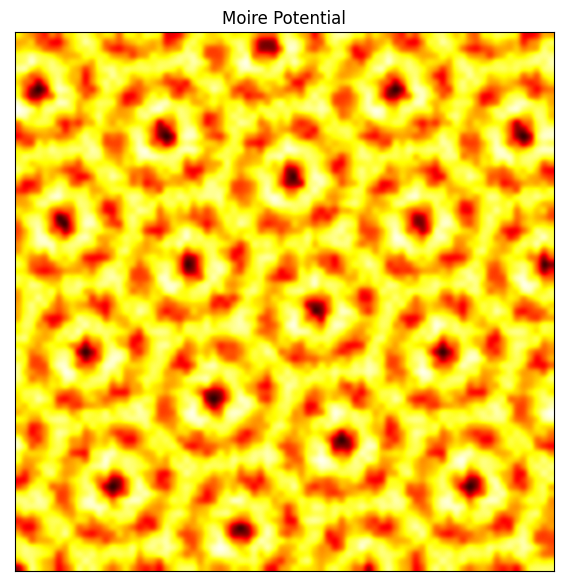

PyObject Text(0.5, 1.0, 'Moire Potential')

In [17]:
figure(figsize=(7, 7))
imshow(np.rot90(EnergyArray), interpolation="gaussian", cmap="hot", alpha=1)
xticks(Float64[])
yticks(Float64[])
title("Moire Potential")

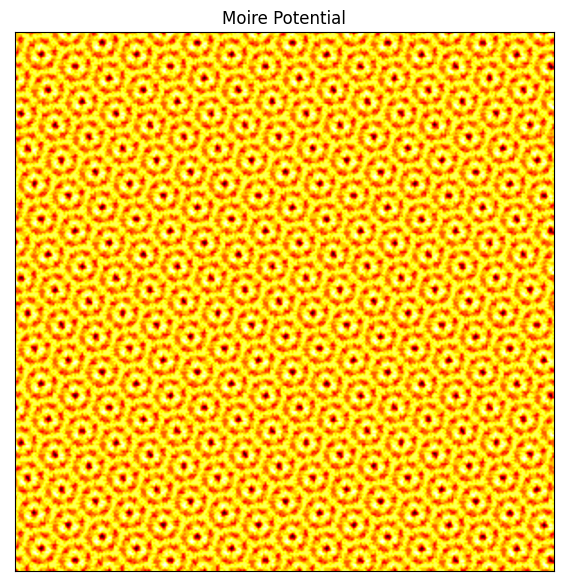

PyObject Text(0.5, 1.0, 'Moire Potential')

In [137]:
figure(figsize=(7, 7))
imshow(np.rot90(EnergyArray), interpolation="gaussian", cmap="hot", alpha=1)
xticks(Float64[])
yticks(Float64[])
title("Moire Potential")

In [32]:
for i in [86, 233, 269, 392]
    j = div(i, 20)
    k = i-j*20
    println(j+1, " ", k)
end

5 6
12 13
14 9
20 12


In [215]:
Moire_Fig = imread("Moire.jpg");


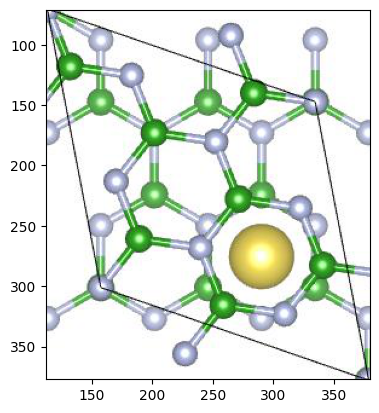

(112.0, 380.0)

In [267]:
imshow(Moire_Fig, alpha=1)
ylim(377, 71)
xlim(112, 380)
#imshow(np.rot90(EnergyArray), interpolation="gaussian", cmap="hot", alpha=0.1)

In [278]:
sqrt(306^2+268^2)/sqrt(3)

234.84746822849368

In [224]:
sqrt((-11.818700)^2+4.09412^2)
 

12.507737136045034

In [227]:
acosd(11.818700/12.507737136045034)

19.106614977903714